In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm
from tqdm import tqdm
np.random.seed(42)
mu = [0, 5, -7]
p = [0.25, 0.3, 0.45]
sigma = 1
n_samples = 10000

def target_f(x):
    return sum([p[j]*norm.pdf(x, mu[j], sigma) for j in range(3)])

proposal_pdf  = lambda x: norm.pdf(x, loc=0, scale=4) #平均數0,變異數1
proposal_sample = lambda n: np.random.normal(0, 4, n)

x_grid = np.linspace(-10, 10, 1000)
ratio = target_f(x_grid)/proposal_pdf(x_grid)
c = np.max(ratio)

accepted = []

trial_count = 0
with tqdm(total=n_samples, desc="Sampling") as pbar:
    while len(accepted)<n_samples:
        x_candidate = proposal_sample(1)[0]
        u = np.random.uniform(0, 1)
        trial_count += 1
        acceptance_ratio = target_f(x_candidate)/(c*proposal_pdf(x_candidate))
        if u < acceptance_ratio:
            accepted.append(x_candidate)
            pbar.update(1)  # 每接受一筆，進度條 +1

print(f"Total attempts to get {n_samples} samples: {trial_count}")
    
accepted = np.array(accepted)
plt.hist(accepted, bins=100, density=True, alpha=0.6, label="Simulated")
plt.plot(x_grid, target_f(x_grid), 'r-', label='True Density')
plt.legend()

Sampling:  96%|█████████▋| 9626/10000 [00:15<00:00, 610.90it/s]


KeyboardInterrupt: 

In [ ]:
from sklearn.mixture import GaussianMixture
X = np.array(accepted).reshape(-1, 1)
means = np.array([[-7], [0], [5]])
weights = np.array([0.25, 0.3, 0.45])
covs = np.array([[[1]], [[1]], [[1]]])
gmm = GaussianMixture(n_components=3, means_init=means, weights_init=weights, precisions_init=1/covs,
                      random_state=42)
model = gmm.fit(X)
print("Estimated means:", model.means_.flatten())
print("Estimated weights:", model.weights_)
print("Estimated variances:", model.covariances_.flatten())

Estimated means: [-6.99400367e+00  1.12373854e-03  4.99393015e+00]
Estimated weights: [0.44217235 0.26087989 0.29694776]
Estimated variances: [1.00199848 1.0064309  0.95243425]


In [ ]:
init_sets = [np.array([[0], [-7], [5]]), np.array([[0], [0], [0]]), np.array([[50], [100], [150]])]

for init_means in init_sets:
    gmm = GaussianMixture(n_components=3, means_init=init_means, weights_init=weights, precisions_init=1/covs,random_state=42)
    model1 = gmm.fit(X)
    print("Init:", init_means.flatten())
    print("→ Means:", model1.means_.flatten())
    print("→ Weights:", model1.weights_)
    print("→ Variances:", model1.covariances_.flatten())

Init: [ 0 -7  5]
→ Means: [ 3.05526960e-04 -6.99397574e+00  4.99316489e+00]
→ Weights: [0.26078554 0.44217592 0.29703854]
→ Variances: [1.00437574 1.00208805 0.95413711]
Init: [0 0 0]
→ Means: [-1.60932555 -1.60932555 -1.60932555]
→ Weights: [0.25 0.3  0.45]
→ Variances: [27.43353037 27.43353037 27.43353037]
Init: [ 50 100 150]
→ Means: [-1.60932555e+00 -1.85051368e-04 -1.85051368e-04]
→ Weights: [1.00000000e+00 5.79499261e-19 5.79499261e-19]
→ Variances: [2.74335304e+01 1.96845963e-06 1.96845963e-06]


Estimated theta after 14 iterations: 0.334077


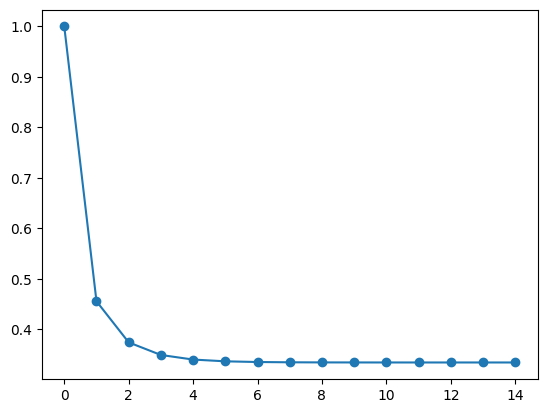

In [ ]:
import numpy as np

y = np.array([1.5, 0.58, 3.4])
y4_ = 1.2; y5_ = 2.3

theta = 1; tol = 1e-6; max_iter = 100

theta_values = [theta]

for i in range(max_iter):
    # E-step
    Ez4 = y4_+1/theta; Ez5 = y5_+1/theta

    # M-step
    theta_new = 5/(np.sum(y)+Ez4+Ez5)
    theta_values.append(theta_new)

    # 收斂檢查
    if abs(theta-theta_new)<tol:
        break
    theta = theta_new

print(f"Estimated theta after {i+1} iterations: {theta:.6f}")

plt.plot(theta_values, marker='o')

Estimated prob after 49 iterations: 0.615055
Estimated lambda after 49 iterations: 1.037835


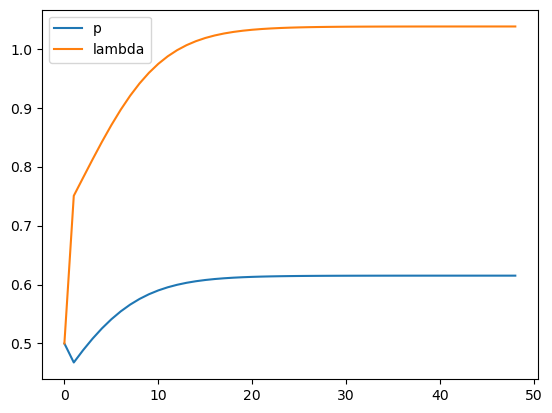

In [20]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
f_x = {0: 3062, 1:587, 2:284, 3:103, 4:33, 5:4, 6:2}
f0 = f_x[0]
f_plus = sum(f_x[x] for x in f_x if x>=1)
n = f0 + f_plus
S_plus = sum([x*f_x[x] for x in f_x if x>-1])
p = 0.5; lambda_ = 0.5; tol = 1e-6; max_iter = 100
history = []
for t in range(max_iter):
    tau = p/(p+(1-p)*np.exp(-lambda_)); E_A = f0*tau; E_B = f0*(1-tau)+f_plus # E-step
    p_new = E_A/n; lambda_new = S_plus/E_B # M-step
    history.append((t, p, lambda_, tau))
    if abs(p-p_new)<tol and abs(lambda_-lambda_new)<tol:
        break
    p, lambda_ = p_new, lambda_new
results = pd.DataFrame(history, columns=['Iteration', 'p', 'lambda', 'tau'])
print(f"Estimated prob after {t+1} iterations: {p:.6f}")
print(f"Estimated lambda after {t+1} iterations: {lambda_:.6f}")
plt.plot(results['Iteration'], results['p'], label='p')
plt.plot(results['Iteration'], results['lambda'], label='lambda')
plt.legend()

In [29]:
data = pd.read_csv('DataFinal.csv', encoding='utf-8')
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   x       200 non-null    float64
 1   y       200 non-null    float64
dtypes: float64(2)
memory usage: 3.3 KB


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   x       200 non-null    float64
 1   y       200 non-null    float64
dtypes: float64(2)
memory usage: 3.3 KB


Text(0, 0.5, 'Y')

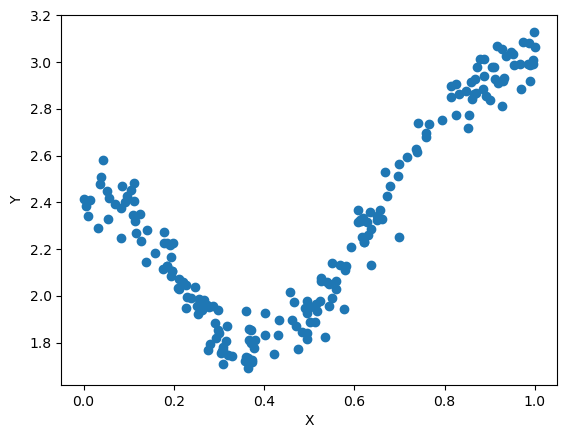

In [37]:
data = pd.read_csv('DataFinal.csv', encoding='utf-8')
data.info()
plt.scatter(data['x'], data['y'])
plt.xlabel('X')
plt.ylabel('Y')

In [35]:
import statsmodels.api as sm
import seaborn as sns
data = pd.read_csv('DataFinal.csv', encoding='utf-8')
X = data['x']
y = data['y']
X_with_constant = sm.add_constant(X)
model = sm.OLS(y, X_with_constant).fit()
model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                      y   R-squared:                       0.449
Model:                            OLS   Adj. R-squared:                  0.446
Method:                 Least Squares   F-statistic:                     161.1
Date:                Tue, 10 Jun 2025   Prob (F-statistic):           2.13e-27
Time:                        15:19:47   Log-Likelihood:                -48.902
No. Observations:                 200   AIC:                             101.8
Df Residuals:                     198   BIC:                             108.4
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          1.8252      0.043     42.147      0.000       1.740       1.911
x              0.9587      0.076     12.693      0.000       0.810       1.108
==============================================================================
Omnibus:                       49.310   Durbin-Watson:                   2.002
Prob(Omnibus):                  0.000   Jarque-Bera (JB):               10.525
Skew:                           0.164   Prob(JB):                      0.00518
Kurtosis:                       1.925   Cond. No.                         4.34
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

Text(0, 0.5, 'Residuals')

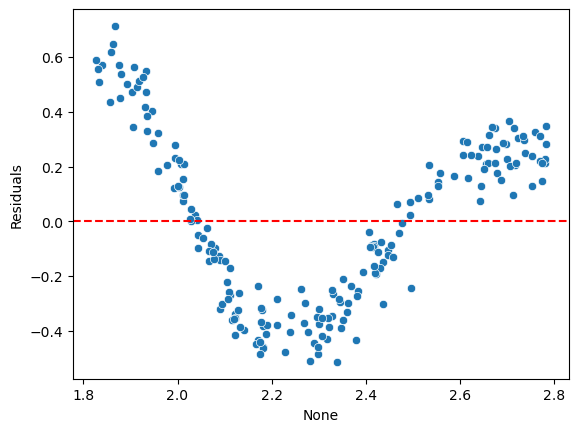

In [42]:
fitted_vals = model.fittedvalues
residuals = model.resid
sns.scatterplot(x=fitted_vals, y=residuals)
plt.axhline(0, color='r', linestyle='--')
plt.ylabel('Residuals')

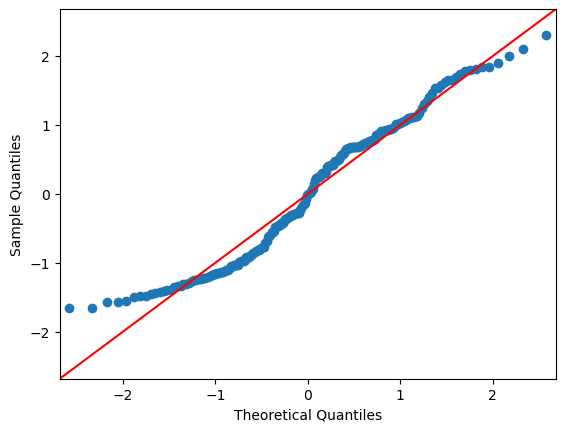

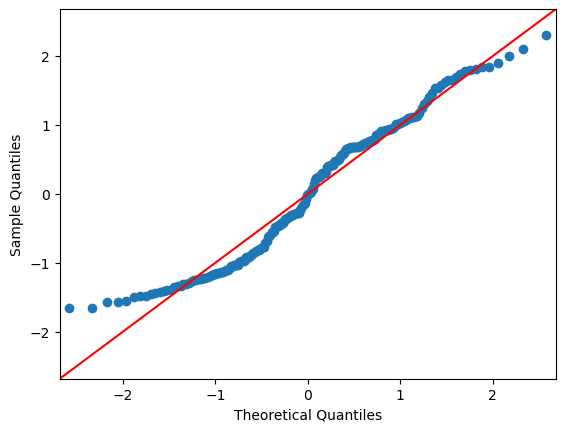

In [46]:
sm.qqplot(residuals, line='45', fit=True, ax=plt.gca())